In [25]:
# Import all libraries:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [14]:
file_path = "cab_rides.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ravi72munde/uber-lyft-cab-prices",
  file_path
)

/tmp/ipykernel_47193/1921303550.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'uber-lyft-cab-prices' dataset.


In [15]:
df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [16]:
df.isna().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [17]:
df = df.dropna()

In [18]:
# Extract datetime features before dropping timestamp
dt = pd.to_datetime(df["time_stamp"], unit="ms")
df["hour"] = dt.dt.hour
df["day_of_week"] = dt.dt.dayofweek

# Drop useless columns
df = df.drop(columns=["id", "product_id", "time_stamp"])

In [19]:
df.head()

,distance,cab_type,destination,source,price,surge_multiplier,name,hour,day_of_week
0,0.44,Lyft,North Station,Haymarket Square,5.0,1.0,Shared,9,6
1,0.44,Lyft,North Station,Haymarket Square,11.0,1.0,Lux,2,1
2,0.44,Lyft,North Station,Haymarket Square,7.0,1.0,Lyft,1,2
3,0.44,Lyft,North Station,Haymarket Square,26.0,1.0,Lux Black XL,4,4
4,0.44,Lyft,North Station,Haymarket Square,9.0,1.0,Lyft XL,3,3


In [20]:
categorical_cols = ["cab_type", "destination", "source", "name"]

numeric_cols = ["distance", "surge_multiplier", "hour", "day_of_week"]

preprocessor  = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ],
)

In [21]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42,
                                    n_estimators = 50,
                                    max_depth = 15,
                                    n_jobs = -1
    ))
])

In [23]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cab_type', 'destination',
                                                   'source', 'name']),
                                                 ('num', 'passthrough',
                                                  ['distance',
                                                   'surge_multiplier', 'hour',
                                                   'day_of_week'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [24]:
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R^2:   {r2:.4f}")

RMSE: 1.67
MAE:  1.08
R^2:   0.9682


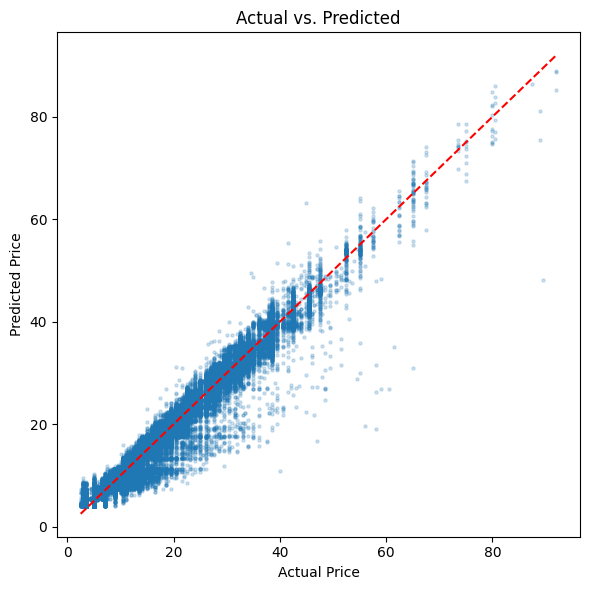

In [26]:
# Actual vs. predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()